# 06b — Surprise + Pattern: Does DTW Improve the Surprise Strategy? — NQ

## Purpose

The original project plan ends with a three-way comparison:

> **Surprise only** vs **Surprise + State** vs **Surprise + Pattern**

Notebooks 04 and 05 covered the first two. This notebook completes the third arm. It adds a **Dynamic Time Warping (DTW)** pattern signal, the method behind the peer strategy (Jack Duncan, Hoshea Zeng), to the surprise strategy of Notebook 05.

**Question:**

> Does the *shape* of the market's price path around a release add information beyond the *surprise* itself?

**Prior evidence (stated before running):** the team has tested DTW for **direction** many times. Jack's six designs, Hoshea's generalisation test and Aaryen's features at an executable entry all failed to establish a directional DTW edge. The expected result is therefore **no improvement**. This notebook is the first test of DTW **as a confirmation of the surprise**, with our executable entry, our universe and our evaluation.

**Credits:** the DTW specification (31-minute z-scored path, same clock slot, 3-year lookback, 600 most recent, k = 15, Sakoe-Chiba band 5, 1/distance × 2-year-half-life recency weights, middle-40% rank gate) is from the peer DTW strategy (**Jack Duncan, Hoshea Zeng**). The "reaction path" ending at T+1 is Jack's design 5.

> **06b — E-mini Nasdaq-100 (NQ).** This notebook is Notebook 06 (ES) run on **NQ**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_NQ.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the NQ contract (tick 0.25, $20 per point).
> - Outputs are saved as `nb06b_NQ_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the NQ results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Load the Notebook 05 trade log (surprise strategies and the traded releases) |
| 3 | Rebuild the release calendar and ES price measures (as in Notebook 05) |
| 4 | Build the DTW signal for every release (walk-forward, history only) |
| 5 | Diagnostics: does DTW predict the 30-minute return? Is it related to the surprise? |
| 6 | Strategies: DTW only, surprise + DTW agreement, 50/50 blend (all releases and CPI) |
| 7 | Performance, robustness and paired tests against surprise only |
| 8 | **Final three-model comparison** (Surprise only / + State / + Pattern) |

## Methodology: fixed before looking at results

**DTW signal for a release at time T.**
1. **Query path:** ES log prices from T−30 to T+1 (32 one-minute points), z-scored. It ends at the entry instant, so it includes the first minute of the market's reaction but nothing after entry.
2. **Library:** earlier releases at the **same clock time** (for example all 08:30 releases, of any type), within the last **3 years**, at most the **600** most recent, and only releases whose outcome was known at T (release time < T − 30 min).
3. **Matching:** DTW distance with a 5-minute Sakoe-Chiba band; the **15** nearest paths, weighted by 1/distance × recency (2-year half-life).
4. **Signal:** `dtw_dir` = weighted mean of the neighbours' T+1 → T+30 returns; `dtw_disp` = their weighted standard deviation; `dtw_score = dtw_dir / dtw_disp`.

**Three pre-registered strategies**, on the same releases and window as Notebook 05 (entry T+1, exit T+30):

| Strategy | Rule |
|---|---|
| **DTW only** | Trade the sign of `dtw_score` only if it is outside the middle 40% of its previous-3-year range (the peer rank gate) |
| **Surprise + DTW agreement** | Keep a surprise trade only if DTW points in the **same direction** |
| **Surprise + DTW blend** | Position = ½ × surprise position + ½ × DTW position |

The surprise baselines are Notebook 05's **All · naive** (≈10 releases) and **CPI · surprise model**. Costs, evaluation window (2019–2026) and tests are the same as Notebook 05.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "NQ"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
NB05_LOG = RESULTS_DIR / f"nb05b_{MARKET}_trade_log.csv"
NB05_FINAL = RESULTS_DIR / f"nb05b_{MARKET}_final_comparison.csv"
NB04_FINAL = RESULTS_DIR / f"nb04b_{MARKET}_final_comparison.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
import src.dtw_signal as ds
for m in (sc, wf, su, ds):
    importlib.reload(m)

for f in [BBG_FILE, MARKET_FILE, NB05_LOG, NB05_FINAL, NB04_FINAL]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
futures_1min_clean_v3_NQ.parquet         exists: True
nb05b_NQ_trade_log.csv                   exists: True
nb05b_NQ_final_comparison.csv            exists: True
nb04b_NQ_final_comparison.csv            exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = NQ | file: futures_1min_clean_v3_NQ.parquet (exists: True) | tick 0.25, $20 per point | cost 2 ticks + $4.50 = 0.7250 points per round trip


### 1.1 Pre-registered parameters

In [3]:
HIST_START = "2016-01-01"
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25

# DTW specification (peer strategy)
LOOKBACK_YEARS, MAX_POOL, K_NN, BAND, HALF_LIFE = 3, 600, 15, 5, 2.0
GATE_MIDDLE = 0.40          # do not trade the middle 40% of the historical score range
N_NULL, N_BOOT = 1000, 5000

SURPRISE_ALL = "All · naive"            # Notebook 05 multi-release baseline
SURPRISE_CPI = "CPI · surprise model"   # Notebook 05 CPI baseline

## 2. Load the Notebook 05 Trade Log

In [4]:
log5 = pd.read_csv(NB05_LOG)
log5["timestamp_utc"] = pd.to_datetime(log5["timestamp_utc"], utc=True)
base_all = log5[log5["strategy"] == SURPRISE_ALL].sort_values("timestamp_utc").reset_index(drop=True)
base_cpi = log5[log5["strategy"] == SURPRISE_CPI].sort_values("timestamp_utc").reset_index(drop=True)
print(f"{SURPRISE_ALL}: {len(base_all)} release timestamps, {int((base_all['position'] != 0).sum())} trades")
print(f"{SURPRISE_CPI}: {len(base_cpi)} release timestamps, {int((base_cpi['position'] != 0).sum())} trades")
display(base_all[["timestamp_utc", "families", "x", "position", "ret_bps", "cost_bps", "net_bps"]].head())

All · naive: 801 release timestamps, 745 trades
CPI · surprise model: 89 release timestamps, 86 trades


,timestamp_utc,families,x,position,ret_bps,cost_bps,net_bps
0,2019-01-03 15:00:00+00:00,ISM Manufacturing,-1.334,-1.000,-13.246,1.160,12.087
1,2019-01-04 13:30:00+00:00,Employment Report (NFP),0.663,1.000,30.449,1.159,29.290
2,2019-01-07 15:00:00+00:00,ISM Services,-0.521,-1.000,20.166,1.125,-21.291
3,2019-01-16 15:00:00+00:00,NAHB Housing Market Index,0.708,1.000,-21.588,1.079,-22.666
4,2019-01-23 15:00:00+00:00,Richmond Fed Manufact. Index,0.000,0.000,-34.718,1.080,-0.000


## 3. Release Calendar and ES Paths

In [5]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)

cal = (rows[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC")]
       .groupby("ts_utc")["clock_et"].first().reset_index().sort_values("ts_utc").reset_index(drop=True))
px = su.price_measures(es_adj, cal["ts_utc"])
cal = cal.merge(px[["ts_utc", "w1"]], on="ts_utc", how="left")

raw_paths = ds.extract_paths(es_adj, cal["ts_utc"])
paths = ds.zscore_rows(raw_paths)
ok = ~np.isnan(raw_paths).any(axis=1)
print(f"Release timestamps since {HIST_START}: {len(cal):,} | with a complete 32-minute path: {ok.sum():,} "
      f"| clock slots: {cal['clock_et'].nunique()} | {time.time()-t0:.0f}s")

# every Notebook 05 release must be in the calendar, with the same trade return
chk = base_all.merge(cal, left_on="timestamp_utc", right_on="ts_utc", how="left")
print("NB05 releases found in calendar:", chk["ts_utc"].notna().mean().round(4))
print("Max |NB05 ret - w1|:", float((chk["ret_bps"] - chk["w1"]).abs().max()))

Release timestamps since 2016-01-01: 6,097 | with a complete 32-minute path: 5,855 | clock slots: 59 | 2s
NB05 releases found in calendar: 1.0
Max |NB05 ret - w1|: 1.4210854715202004e-14


## 4. DTW Signal (walk-forward)

For every release since 2017, the 15 most similar earlier paths at the same clock time are found, using only releases whose outcome was already known. This takes about 20–60 seconds.

In [6]:
t0 = time.time()
qmask = (cal["ts_utc"] >= pd.Timestamp("2017-01-01", tz="UTC")).to_numpy()
sig = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths, cal["w1"].to_numpy(),
                            query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                            k=K_NN, band=BAND, half_life_years=HALF_LIFE)
print(f"DTW signal computed for {sig['dtw_dir'].notna().sum():,} releases in {time.time()-t0:.0f}s")
display(sig.dropna().describe().T[["count", "mean", "std", "min", "50%", "max"]])

gates = ds.gate_thresholds(sig, EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
display(pd.DataFrame(gates, index=["lower cut", "upper cut", "n history"]).T)
sig.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_dtw_signal.csv", index=False)

  DTW computed for 1,000 releases ...
  DTW computed for 2,000 releases ...
  DTW computed for 3,000 releases ...
  DTW computed for 4,000 releases ...
  DTW computed for 5,000 releases ...
DTW signal computed for 5,229 releases in 4s


,count,mean,std,min,50%,max
dtw_dir,"5,229.000",-0.061,7.720,-54.614,0.205,33.296
dtw_disp,"5,229.000",23.567,13.777,0.000,21.299,118.890
pool,"5,229.000",378.105,215.580,30.000,422.000,600.000
nn_dist,"5,229.000",1.953,0.904,0.000,1.808,5.657
dtw_score,"5,229.000",0.013,0.305,-1.122,0.012,1.204


,lower cut,upper cut,n history
2019,-0.126,0.190,"1,007.000"
2020,-0.139,0.187,"1,569.000"
2021,-0.150,0.182,"1,661.000"
2022,-0.150,0.183,"1,714.000"
2023,-0.146,0.172,"1,666.000"
2024,-0.143,0.175,"1,640.000"
2025,-0.147,0.163,"1,631.000"
2026,-0.155,0.166,"1,665.000"


## 5. Diagnostics

### 5.1 Does the DTW signal predict the 30-minute return?

In [7]:
ev = sig.merge(cal[["ts_utc", "w1"]], on="ts_utc")
ev = ev[(ev["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) & ev["dtw_dir"].notna() & ev["w1"].notna()]
traded_ts = set(base_all["timestamp_utc"])
ev["in_nb05_universe"] = ev["ts_utc"].isin(traded_ts)

def ic_row(d, label):
    return dict(sample=label, n=len(d),
                rank_ic=d["dtw_score"].corr(d["w1"], method="spearman"),
                pearson_ic=d["dtw_dir"].corr(d["w1"]),
                hit_sign=(np.sign(d["dtw_dir"]) == np.sign(d["w1"])).mean())
diag = pd.DataFrame([ic_row(ev, "all releases 2019-26"),
                     ic_row(ev[ev["in_nb05_universe"]], "NB05 traded releases"),
                     ic_row(ev[ev["clock"] == "08:30"], "08:30 releases"),
                     ic_row(ev[ev["clock"] == "10:00"], "10:00 releases")]).set_index("sample")
display(diag.round(4))

yearly_ic = ev.groupby(ev["ts_utc"].dt.year).apply(lambda d: d["dtw_score"].corr(d["w1"], method="spearman")).rename("rank IC")
display(yearly_ic.to_frame().T.round(3))

,n,rank_ic,pearson_ic,hit_sign
sample,,,,
all releases 2019-26,4097,0.026,0.009,0.509
NB05 traded releases,779,0.028,0.019,0.499
08:30 releases,1096,0.032,0.051,0.504
10:00 releases,1012,0.025,-0.007,0.523


ts_utc,2019,2020,2021,2022,2023,2024,2025,2026
rank IC,0.071,0.025,0.043,0.006,0.005,0.008,0.051,-0.024


**How to read it.** A rank IC around 0 means DTW has no directional information. Useful directional signals in this setting typically show an IC of about 0.05–0.10, stable across years. The hit rate should be compared with 50%.

### 5.2 Is DTW related to the surprise?

In [8]:
m = base_all.merge(sig, left_on="timestamp_utc", right_on="ts_utc", how="inner").dropna(subset=["dtw_dir", "x"])
rel = pd.Series({
    "corr(dtw_score, surprise x)": m["dtw_score"].corr(m["x"], method="spearman"),
    "share of releases where signs agree": (np.sign(m["dtw_dir"]) == np.sign(m["x"])).mean(),
    "n releases": len(m),
})
display(rel.to_frame("value").round(3))

,value
"corr(dtw_score, surprise x)",0.068
share of releases where signs agree,0.500
n releases,800.000


The DTW path ends one minute after the release, so it contains the first reaction to the surprise. A positive correlation means DTW partly **re-measures the surprise**. What matters is whether it adds information **beyond** it.

## 6. Strategies

In [9]:
def attach(base):
    t = base.merge(sig[["ts_utc", "dtw_dir", "dtw_disp", "dtw_score"]], left_on="timestamp_utc",
                   right_on="ts_utc", how="left").drop(columns="ts_utc")
    y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
    lo = y.map(lambda v: gates[v][0]); hi = y.map(lambda v: gates[v][1])
    s = t["dtw_score"]
    t["dtw_pos"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
    t["dtw_pos"] = t["dtw_pos"].fillna(0.0)
    return t

def build(base, tag):
    t = attach(base)
    out = {}
    out[f"{tag} · surprise only"] = ds.recost(t, f"{tag} · surprise only")
    d = t.copy(); d["position"] = d["dtw_pos"]
    out[f"{tag} · DTW only"] = ds.recost(d, f"{tag} · DTW only")
    a = t.copy(); a["position"] = np.where(np.sign(a["dtw_dir"]) == np.sign(a["position"]), a["position"], 0.0)
    out[f"{tag} · surprise + DTW agree"] = ds.recost(a, f"{tag} · surprise + DTW agree")
    b = t.copy(); b["position"] = 0.5 * b["position"] + 0.5 * b["dtw_pos"]
    out[f"{tag} · surprise + DTW blend"] = ds.recost(b, f"{tag} · surprise + DTW blend")
    return out

T = {**build(base_all, "All"), **build(base_cpi, "CPI")}
STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / f"nb06b_{MARKET}_trade_log.csv", index=False)
display(pd.DataFrame({k: {"trades": int((v["position"] != 0).sum()),
                          "trades / yr": (v["position"] != 0).sum() / N_YEARS} for k, v in T.items()}).T.round(1))

,trades,trades / yr
All · surprise only,745.000,99.400
All · DTW only,488.000,65.100
All · surprise + DTW agree,390.000,52.000
All · surprise + DTW blend,572.000,76.300
CPI · surprise only,86.000,11.500
CPI · DTW only,57.000,7.600
CPI · surprise + DTW agree,54.000,7.200
CPI · surprise + DTW blend,72.000,9.600


## 7. Performance

### 7.1 Main metrics (2019–2026, net of costs)

In [10]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_net_bps", "total_net_pct", "ann_return_pct",
       "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_performance.csv")
display(perf[["trades_per_year"] + KEY].round(3))

,trades_per_year,trades,hit_rate,avg_gross_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,
All · surprise only,96.751,725,0.530,2.957,2.412,17.484,2.331,3.276,0.872,0.712,-5.662,1.923,1.221
All · DTW only,63.121,473,0.503,0.886,0.345,1.631,0.218,2.633,0.212,0.083,-8.282,0.212,1.028
All · surprise + DTW agree,50.844,381,0.535,3.654,3.107,11.838,1.578,2.543,0.729,0.621,-6.716,1.779,1.291
All · surprise + DTW blend,74.465,558,0.518,2.297,1.913,10.677,1.424,2.133,0.800,0.667,-5.561,1.712,1.249
CPI · surprise only,11.477,86,0.535,7.668,7.120,6.123,0.816,1.472,0.597,0.554,-2.743,1.519,1.620
CPI · DTW only,7.607,57,0.596,14.355,13.837,7.887,1.052,1.306,0.835,0.805,-2.072,2.234,2.413
CPI · surprise + DTW agree,7.206,54,0.537,10.591,10.055,5.430,0.724,1.339,0.569,0.540,-2.382,1.487,1.783
CPI · surprise + DTW blend,9.608,72,0.556,10.262,9.835,7.081,0.944,1.310,0.751,0.721,-2.299,1.982,2.100


### 7.2 Robustness and paired comparison with surprise only

In [11]:
def sharpe_m(tr, a, b, drop_year=None):
    m = wf.monthly_returns(tr, a, b)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rows_r = []
for s in STRATS:
    base_name = s.split(" · ")[0] + " · surprise only"
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    row = dict(strategy=s, sharpe=obs,
               sharpe_2019_21=sharpe_m(T[s], "2019-01-01", "2021-12-31"),
               sharpe_2022_26=sharpe_m(T[s], "2022-01-01", EVAL_END),
               sharpe_ex_2022=sharpe_m(T[s], EVAL_START, EVAL_END, 2022),
               p_random_sign=p_null)
    if s != base_name:
        d, (lo, _, hi), p = wf.bootstrap_sharpe_diff(T[base_name], T[s], EVAL_START, EVAL_END, N_BOOT)
        pt = wf.paired_trade_test(T[base_name], T[s], EVAL_START, EVAL_END)
        row.update(sharpe_diff_vs_surprise=d, diff_ci_5=lo, diff_ci_95=hi, p_not_better=p,
                   paired_t=pt["t_stat"])
    rows_r.append(row)
rob = pd.DataFrame(rows_r).set_index("strategy")
rob.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_robustness.csv")
display(rob.round(3))

,sharpe,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign,sharpe_diff_vs_surprise,diff_ci_5,diff_ci_95,p_not_better,paired_t
strategy,,,,,,,,,,
All · surprise only,0.712,0.352,0.905,0.439,0.005,NaN,NaN,NaN,NaN,NaN
All · DTW only,0.083,0.916,-0.314,0.171,0.271,-0.629,-1.457,0.284,0.872,-1.402
All · surprise + DTW agree,0.621,0.613,0.634,0.588,0.021,-0.091,-0.487,0.382,0.595,-0.911
All · surprise + DTW blend,0.667,0.957,0.538,0.512,0.013,-0.044,-0.396,0.404,0.525,-1.203
CPI · surprise only,0.554,0.777,0.488,-0.014,0.047,NaN,NaN,NaN,NaN,NaN
CPI · DTW only,0.805,0.697,0.916,0.187,0.011,0.251,-0.183,0.745,0.163,0.690
CPI · surprise + DTW agree,0.540,0.762,0.549,-0.051,0.057,-0.014,-0.308,0.302,0.540,-0.408
CPI · surprise + DTW blend,0.721,1.004,0.718,0.099,0.017,0.166,-0.038,0.418,0.090,0.749


**How to read it.**
- **`p_not_better`** is the bootstrap probability that adding DTW is *not* better than surprise only. Below 0.05 would be convincing evidence that DTW helps.
- **`p_random_sign`** tests whether the direction beats random directions with the same trades and costs.

### 7.3 Cumulative P&L

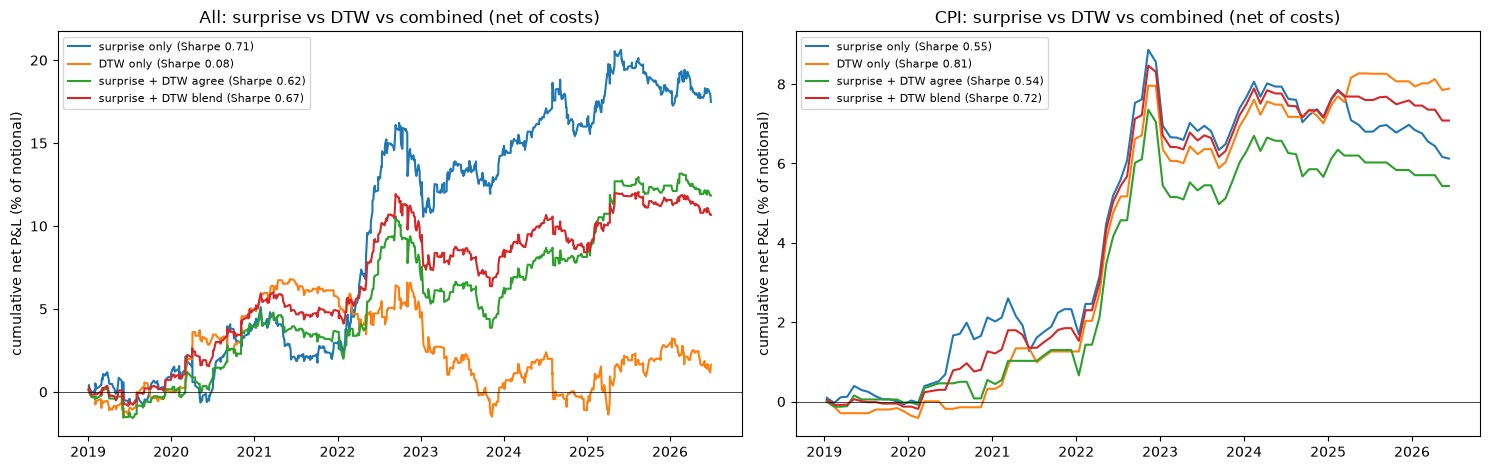

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
for ax, tag in zip(axes, ["All", "CPI"]):
    for i, suffix in enumerate(["surprise only", "DTW only", "surprise + DTW agree", "surprise + DTW blend"]):
        s = f"{tag} · {suffix}"
        cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
        ax.plot(cum.index, cum.values, lw=1.5, label=f"{suffix} (Sharpe {perf.loc[s, 'sharpe_net']:.2f})")
    ax.axhline(0, c="k", lw=0.5)
    ax.set_title(f"{tag}: surprise vs DTW vs combined (net of costs)")
    ax.set_ylabel("cumulative net P&L (% of notional)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_cumulative_pnl.png", dpi=150); plt.show()

### 7.4 When surprise and DTW disagree

In [13]:
t = attach(base_all)
t = t[(t["position"] != 0) & t["dtw_dir"].notna()]
t["net"] = t["position"] * t["ret_bps"] - t["cost_bps"]
t["dtw_agrees"] = np.sign(t["dtw_dir"]) == np.sign(t["position"])
agree_tab = t.groupby("dtw_agrees")["net"].agg(trades="size", hit_rate=lambda v: (v > 0).mean(),
                                               avg_net_bps="mean", total_net_pct=lambda v: v.sum() / 100)
display(agree_tab.round(3))

,trades,hit_rate,avg_net_bps,total_net_pct
dtw_agrees,,,,
False,354,0.506,1.608,5.516
True,390,0.523,3.106,11.833


If DTW adds information, surprise trades where **DTW agrees** should clearly beat those where it **disagrees**. Similar numbers in both rows mean DTW is not separating good trades from bad ones.

## 8. Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern

In [14]:
rows_f = []
if NB04_FINAL.exists():
    f4 = pd.read_csv(NB04_FINAL, index_col=[0, 1])
    for strat, label in [("Surprise only", "Surprise only — CPI (NB04)"),
                         ("Surprise + State", "Surprise + State — CPI (NB04)"),
                         ("Surprise + Adaptive state", "Surprise + Adaptive state — CPI (NB04)")]:
        if ("CPI", strat) in f4.index:
            r = f4.loc[("CPI", strat)]
            rows_f.append(dict(model=label, trades_per_year=r["trades"] / N_YEARS, net_bps_per_trade=r["avg_net_bps"],
                               sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"]))
for s, label in [("All · surprise only", "Surprise only — ~10 releases (NB05)"),
                 ("CPI · surprise only", "Surprise only — CPI model (NB05)"),
                 ("All · surprise + DTW agree", "Surprise + Pattern (agree) — ~10 releases"),
                 ("All · surprise + DTW blend", "Surprise + Pattern (blend) — ~10 releases"),
                 ("CPI · surprise + DTW agree", "Surprise + Pattern (agree) — CPI"),
                 ("All · DTW only", "Pattern only (DTW) — ~10 releases")]:
    r = perf.loc[s]
    rows_f.append(dict(model=label, trades_per_year=r["trades_per_year"], net_bps_per_trade=r["avg_net_bps"],
                       sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"],
                       sharpe_ex_2022=rob.loc[s, "sharpe_ex_2022"], p_random_sign=rob.loc[s, "p_random_sign"]))
rows_f.append(dict(model="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, net_bps_per_trade=1.18,
                   sharpe_net=0.613, max_dd_pct=-4.928))
final = pd.DataFrame(rows_f).set_index("model")
final.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_final_three_model_comparison.csv")
display(final.round(3))

,trades_per_year,net_bps_per_trade,sharpe_net,max_dd_pct,sharpe_ex_2022,p_random_sign
model,,,,,,
Surprise only — CPI (NB04),8.274,12.124,0.794,-2.047,NaN,NaN
Surprise + State — CPI (NB04),8.541,11.190,0.747,-2.743,NaN,NaN
Surprise + Adaptive state — CPI (NB04),8.541,11.190,0.747,-2.743,NaN,NaN
Surprise only — ~10 releases (NB05),96.751,2.412,0.712,-5.662,0.439,0.005
Surprise only — CPI model (NB05),11.477,7.120,0.554,-2.743,-0.014,0.047
Surprise + Pattern (agree) — ~10 releases,50.844,3.107,0.621,-6.716,0.588,0.021
Surprise + Pattern (blend) — ~10 releases,74.465,1.913,0.667,-5.561,0.512,0.013
Surprise + Pattern (agree) — CPI,7.206,10.055,0.540,-2.382,-0.051,0.057
Pattern only (DTW) — ~10 releases,63.121,0.345,0.083,-8.282,0.171,0.271


### 8.1 Automatic summary

In [15]:
print("=" * 100)
print(f"NOTEBOOK 06 SUMMARY — does DTW add to the surprise? ({MARKET}, 2019-2026, net of costs)")
print("=" * 100)
print("DTW directional information (rank IC vs 30-min return):")
for k, r in diag.iterrows():
    print(f"  {k:<28s} n={int(r.n):>5d}  rank IC={r.rank_ic:+.4f}  hit={r.hit_sign:.1%}")
print()
for s in STRATS:
    r = perf.loc[s]; q = rob.loc[s]
    extra = "" if pd.isna(q.get("p_not_better", np.nan)) else f" | vs surprise: ΔSharpe {q['sharpe_diff_vs_surprise']:+.2f}, P(not better) {q['p_not_better']:.2f}"
    print(f"{s:<32s} {r.trades_per_year:5.0f} tr/yr | Sharpe {r.sharpe_net:5.2f} | {r.avg_net_bps:6.2f} bps | "
          f"random-sign p {q['p_random_sign']:.3f}{extra}")

NOTEBOOK 06 SUMMARY — does DTW add to the surprise? (NQ, 2019-2026, net of costs)
DTW directional information (rank IC vs 30-min return):
  all releases 2019-26         n= 4097  rank IC=+0.0257  hit=50.9%
  NB05 traded releases         n=  779  rank IC=+0.0281  hit=49.9%
  08:30 releases               n= 1096  rank IC=+0.0317  hit=50.4%
  10:00 releases               n= 1012  rank IC=+0.0252  hit=52.3%

All · surprise only                 97 tr/yr | Sharpe  0.71 |   2.41 bps | random-sign p 0.005
All · DTW only                      63 tr/yr | Sharpe  0.08 |   0.34 bps | random-sign p 0.271 | vs surprise: ΔSharpe -0.63, P(not better) 0.87
All · surprise + DTW agree          51 tr/yr | Sharpe  0.62 |   3.11 bps | random-sign p 0.021 | vs surprise: ΔSharpe -0.09, P(not better) 0.60
All · surprise + DTW blend          74 tr/yr | Sharpe  0.67 |   1.91 bps | random-sign p 0.013 | vs surprise: ΔSharpe -0.04, P(not better) 0.52
CPI · surprise only                 11 tr/yr | Sharpe  0.55 |   7.

## 9. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Does DTW predict direction by itself?** Use the rank IC (Section 5.1) and the DTW-only strategy.

**2. Is DTW just re-measuring the surprise?** Use the correlation between the DTW score and the surprise (Section 5.2).

**3. Does DTW improve the surprise strategy?** Compare the agreement and blend strategies with surprise only: Sharpe difference, `P(not better)`, and agree-vs-disagree trades (Section 7.4).

**4. Final three-model answer.** Surprise only vs Surprise + State vs Surprise + Pattern: which one would you recommend, and how confident are you?

# 10. Extra Test: The Ladder: Can We Reach ~185 Trades a Year?

## Why this test

The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES** because it takes **five consecutive 30-minute trades after each release** (T+1, T+31, T+61, T+91, T+121). Our books take **one trade per release**, which caps them at about 108 trades a year on our universe.

This section copies the ladder structure to answer the supervisor's question directly:

> **If we trade five windows after each release, how many trades do we get, and what happens to the Sharpe?**

## Design (fixed before running)

| Window | Entry → exit (bars after the release) | Approx. clock time for an 08:30 release |
|---|---|---|
| 1 | close of bar T → T+29 (same as Sections 1–9) | 08:31 → 09:00 |
| 2 | T+29 → T+59 | 09:00 → 09:30 |
| 3 | T+59 → T+89 | 09:30 → 10:00 |
| 4 | T+89 → T+119 | 10:00 → 10:30 |
| 5 | T+119 → T+149 | 10:30 → 11:00 |

- **Releases:** the same ~108 release timestamps a year as Notebook 05's multi-release book.
- **DTW for window k:** the 31-minute path ending at **that window's entry**, matched against earlier releases at the same clock time, with the neighbours' **window-k** returns as the answer. Neighbours must have finished window k before the current release. The same k = 15, band, lookback, weights and middle-40% gate apply, with the gate computed separately for each window.
- **Surprise for window k:** the sign of the release's surprise (Notebook 05 naive rule), held for that window.
- **Costs:** the same round-trip cost for every window.

**Three books:**
1. **DTW ladder:** DTW in all five windows (closest to the peer structure).
2. **Surprise ladder:** the surprise sign in all five windows.
3. **Surprise W1 + DTW W2–5:** the surprise for the first window, then DTW for the later ones.

**Expected result (stated before running):** Notebook 05 found the surprise's effect is gone within about 30 minutes (window 2 Sharpe −0.79), and Section 5 found no DTW direction in window 1. We therefore expect the trade count to reach the peer's level while the Sharpe falls toward zero.

**Note:** later windows of an 08:30 release can overlap the first window of a 10:00 release on the same day. Each window is treated as a separate trade on one contract, as in the peer strategy.

## 10.1 Window returns and DTW signals for each window

In [16]:
t0 = time.time()
lad = ds.ladder_returns(es_adj, cal["ts_utc"])
assert np.nanmax(np.abs(lad["r1"].to_numpy() - cal["w1"].to_numpy())) < 1e-9, "window 1 must equal w1"
print("Window 1 identical to the Sections 1-9 trade return: OK")

sigs, lgates = {}, {}
for k, (a, b) in enumerate(ds.LADDER, start=1):
    raw_k = ds.extract_paths(es_adj, cal["ts_utc"], end_offset_min=a)
    paths_k = ds.zscore_rows(raw_k)
    sigs[k] = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths_k, lad[f"r{k}"].to_numpy(),
                                    query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                                    k=K_NN, band=BAND, half_life_years=HALF_LIFE, progress_every=0,
                                    min_gap_min=b + 1)
    lgates[k] = ds.gate_thresholds(sigs[k], EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
    print(f"Window {k} (bars {a:>3d} -> {b:>3d}): DTW computed for {sigs[k]['dtw_dir'].notna().sum():,} releases")
print(f"Done in {time.time()-t0:.0f}s")

Window 1 identical to the Sections 1-9 trade return: OK
Window 1 (bars   0 ->  29): DTW computed for 5,229 releases
Window 2 (bars  29 ->  59): DTW computed for 5,218 releases
Window 3 (bars  59 ->  89): DTW computed for 5,122 releases
Window 4 (bars  89 -> 119): DTW computed for 5,117 releases
Window 5 (bars 119 -> 149): DTW computed for 5,010 releases
Done in 21s


## 10.2 Build the ladder books

In [17]:
uni = base_all[["timestamp_utc", "position", "x", "cost_bps"]].rename(columns={"position": "surp_pos"})

def window_trades(k, rule):
    a, b = ds.LADDER[k - 1]
    t = uni.merge(lad[["ts_utc", f"r{k}"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t = t.merge(sigs[k][["ts_utc", "dtw_dir", "dtw_score"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t["ret_bps"] = t[f"r{k}"]
    if rule == "dtw":
        y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
        lo = y.map(lambda v: lgates[k][v][0]); hi = y.map(lambda v: lgates[k][v][1])
        s = t["dtw_score"]
        t["position"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
        t["position"] = pd.Series(t["position"]).fillna(0.0).to_numpy()
    else:
        t["position"] = t["surp_pos"]
    t["eligible"] = t["ret_bps"].notna()
    t["release_ts"] = t["timestamp_utc"]
    t["timestamp_utc"] = t["timestamp_utc"] + pd.Timedelta(minutes=a + 1)   # when the trade is entered
    t["window"] = k
    return ds.recost(t, f"{rule} W{k}")

W = {(rule, k): window_trades(k, rule) for rule in ["dtw", "surprise"] for k in range(1, 6)}

def book(parts, name):
    return ds.recost(pd.concat(parts).sort_values("timestamp_utc").reset_index(drop=True), name)

L = {
    "Surprise W1 only (Sections 1-9)": W[("surprise", 1)].assign(strategy="Surprise W1 only (Sections 1-9)"),
    "DTW ladder (5 windows)": book([W[("dtw", k)] for k in range(1, 6)], "DTW ladder (5 windows)"),
    "Surprise ladder (5 windows)": book([W[("surprise", k)] for k in range(1, 6)], "Surprise ladder (5 windows)"),
    "Surprise W1 + DTW W2-5": book([W[("surprise", 1)]] + [W[("dtw", k)] for k in range(2, 6)], "Surprise W1 + DTW W2-5"),
}
pd.concat(L.values()).to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_trade_log.csv", index=False)

## 10.3 Results by window

rank_ic          trades_per_year          avg_net_bps          sharpe_net         
rule                      dtw surprise             dtw surprise         dtw surprise        dtw surprise
window bars                                                                                             
1      T+0 -> T+29      0.028    0.088          63.121   96.751       0.345    2.412      0.083    0.712
2      T+29 -> T+59    -0.008   -0.014          61.120   96.751       0.023   -0.638      0.007   -0.227
3      T+59 -> T+89    -0.007   -0.056          59.919   96.751      -1.126   -2.158     -0.226   -0.501
4      T+89 -> T+119    0.018    0.022          63.922   96.751       0.729    0.750      0.147    0.230
5      T+119 -> T+149  -0.011   -0.041          60.586   96.751      -0.683   -2.339     -0.176   -0.956

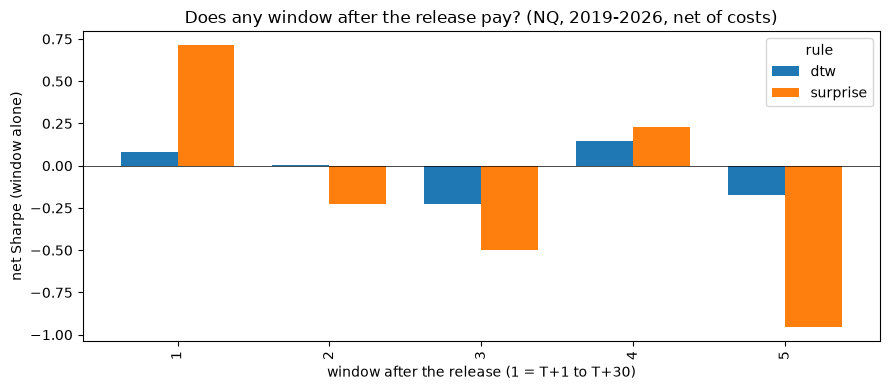

In [18]:
rows_w = []
for k in range(1, 6):
    for rule in ["surprise", "dtw"]:
        t = W[(rule, k)]
        p = wf.performance(t, EVAL_START, EVAL_END, f"{rule} W{k}")
        e = t[t["eligible"] & (t["release_ts"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
        ic = e["dtw_score"].corr(e["ret_bps"], method="spearman") if rule == "dtw" else e["x"].corr(e["ret_bps"], method="spearman")
        rows_w.append(dict(window=k, rule=rule, bars=f"T+{ds.LADDER[k-1][0]} -> T+{ds.LADDER[k-1][1]}",
                           rank_ic=ic, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                           avg_net_bps=p["avg_net_bps"], sharpe_net=p["sharpe_net"], total_net_pct=p["total_net_pct"]))
by_window = pd.DataFrame(rows_w)
by_window.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_by_window.csv", index=False)
display(by_window.pivot(index=["window", "bars"], columns="rule",
                        values=["rank_ic", "trades_per_year", "avg_net_bps", "sharpe_net"]).round(3))

fig, ax = plt.subplots(figsize=(9, 4))
piv = by_window.pivot(index="window", columns="rule", values="sharpe_net")
piv.plot.bar(ax=ax, width=0.75)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net Sharpe (window alone)")
ax.set_xlabel("window after the release (1 = T+1 to T+30)")
ax.set_title(f"Does any window after the release pay? ({MARKET}, 2019-2026, net of costs)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_ladder_sharpe_by_window.png", dpi=150); plt.show()

**How to read it.** Window 1 is the trade used in Sections 1–9. If the ladder were worth trading, windows 2–5 would show positive Sharpe and a positive rank IC. For the surprise, the rank IC is the correlation between the surprise and that window's return.

## 10.4 Ladder books: trade count vs Sharpe

,trades_per_year,hit_rate,avg_net_bps,total_net_pct,sharpe_net,sharpe_ex_2022,max_dd_pct,p_random_sign
book,,,,,,,,
Surprise W1 only (Sections 1-9),96.751,0.530,2.412,17.484,0.712,0.439,-5.662,0.005
DTW ladder (5 windows),308.668,0.498,-0.127,-2.927,-0.065,-0.167,-24.181,0.285
Surprise ladder (5 windows),483.753,0.498,-0.395,-14.314,-0.286,-0.212,-23.582,0.434
Surprise W1 + DTW W2-5,342.297,0.506,0.504,12.926,0.269,-0.036,-15.587,0.064
"Peer: Jack DTW (slide, 2018-26)",185.000,NaN,1.180,18.597,0.613,NaN,-4.928,NaN


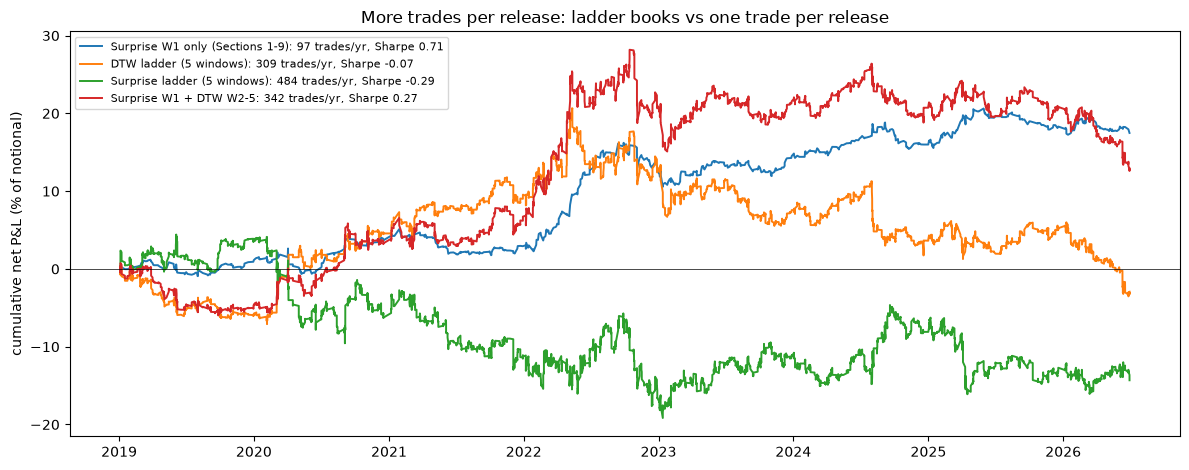

In [19]:
rows_b = []
for name, t in L.items():
    p = wf.performance(t, EVAL_START, EVAL_END, name)
    obs, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    rows_b.append(dict(book=name, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                       avg_net_bps=p["avg_net_bps"], total_net_pct=p["total_net_pct"],
                       sharpe_net=p["sharpe_net"], sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022),
                       max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
rows_b.append(dict(book="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, avg_net_bps=1.18,
                   total_net_pct=18.597, sharpe_net=0.613, max_dd_pct=-4.928))
ladder_tab = pd.DataFrame(rows_b).set_index("book")
ladder_tab.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_books.csv")
display(ladder_tab.round(3))

fig, ax = plt.subplots(figsize=(12, 4.8))
for name, t in L.items():
    cum, _ = wf.drawdown_series(t, EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, lw=1.4,
            label=f"{name}: {ladder_tab.loc[name, 'trades_per_year']:.0f} trades/yr, Sharpe {ladder_tab.loc[name, 'sharpe_net']:.2f}")
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title("More trades per release: ladder books vs one trade per release")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_ladder_cumulative.png", dpi=150); plt.show()

## 10.5 Summary of the ladder test

In [20]:
print("=" * 100)
print(f"LADDER TEST — five 30-minute windows per release ({MARKET}, 2019-2026, net of costs)")
print("=" * 100)
print("By window (net Sharpe of that window alone):")
for k in range(1, 6):
    s = by_window[(by_window.window == k) & (by_window.rule == "surprise")].iloc[0]
    d = by_window[(by_window.window == k) & (by_window.rule == "dtw")].iloc[0]
    print(f"  W{k} {s.bars:<16s} surprise: IC {s.rank_ic:+.3f}, Sharpe {s.sharpe_net:+.2f} | "
          f"DTW: IC {d.rank_ic:+.3f}, Sharpe {d.sharpe_net:+.2f}, {d.trades_per_year:.0f} tr/yr")
print("\nBooks:")
for name, r in ladder_tab.iterrows():
    print(f"  {name:<34s} {r.trades_per_year:6.0f} trades/yr | {r.avg_net_bps:6.2f} bps/trade | "
          f"Sharpe {r.sharpe_net:5.2f} | maxDD {r.max_dd_pct:6.2f}%")

LADDER TEST — five 30-minute windows per release (NQ, 2019-2026, net of costs)
By window (net Sharpe of that window alone):
  W1 T+0 -> T+29      surprise: IC +0.088, Sharpe +0.71 | DTW: IC +0.028, Sharpe +0.08, 63 tr/yr
  W2 T+29 -> T+59     surprise: IC -0.014, Sharpe -0.23 | DTW: IC -0.008, Sharpe +0.01, 61 tr/yr
  W3 T+59 -> T+89     surprise: IC -0.056, Sharpe -0.50 | DTW: IC -0.007, Sharpe -0.23, 60 tr/yr
  W4 T+89 -> T+119    surprise: IC +0.022, Sharpe +0.23 | DTW: IC +0.018, Sharpe +0.15, 64 tr/yr
  W5 T+119 -> T+149   surprise: IC -0.041, Sharpe -0.96 | DTW: IC -0.011, Sharpe -0.18, 61 tr/yr

Books:
  Surprise W1 only (Sections 1-9)        97 trades/yr |   2.41 bps/trade | Sharpe  0.71 | maxDD  -5.66%
  DTW ladder (5 windows)                309 trades/yr |  -0.13 bps/trade | Sharpe -0.07 | maxDD -24.18%
  Surprise ladder (5 windows)           484 trades/yr |  -0.39 bps/trade | Sharpe -0.29 | maxDD -23.58%
  Surprise W1 + DTW W2-5                342 trades/yr |   0.50 bps/trad

### 10.6 Interpretation (fill in after running)

**1. Trade count:** how close does each ladder book get to the peer's 185 trades a year?

**2. Which windows pay?** Is window 1 the only one with a positive edge, for the surprise and for DTW?

**3. Trade count vs Sharpe:** does adding windows raise or lower the Sharpe compared with one trade per release (Sharpe 0.65 at ~98 trades a year)?

**4. Answer for the supervisor:** can we honestly reach ~185 trades a year, and at what cost in risk-adjusted return?

# Purpose, Research Questions, Answers, and Conclusion (NQ)

## Purpose of Notebook 06b (NQ)

Notebook 06 showed for ES that a DTW pattern signal adds no directional information to the macro surprise. Notebook 05b showed that the multi-release surprise book works even better on NQ (Sharpe 0.71).

Notebook 06b repeats Notebook 06 on NQ:

> **Does the shape of NQ's price path around a release add information beyond the surprise itself?**

**Design (identical to Notebook 06):** the peer DTW specification (31-minute z-scored path ending at entry, same clock slot, 3-year lookback, 600 most recent, k = 15, band 5, 1/distance × 2-year half-life weights, middle-40% gate), built on **NQ prices**, with the releases, entry, exit, costs and window of Notebook 05b.

**Checks:** every Notebook 05b release was found, with identical trade returns (difference 1.4×10⁻¹⁴ bps).

---

## Research Questions and Answers

### Section 4: Can a DTW signal be built for every release?
**Answer:** Yes. DTW was computed for **5,229 releases**, each matched against an average of about 378 earlier releases at the same clock time, using only past information.

### Section 5.1: Does DTW predict the 30-minute return by itself?
**Answer:** **Hardly.**

| Sample (2019–2026) | Releases | Rank IC | Hit rate |
|---|---|---|---|
| All releases | 4,097 | +0.026 | 50.9% |
| Releases traded in Notebook 05b | 779 | +0.028 | 49.9% |
| 08:30 releases | 1,096 | +0.032 | 50.4% |
| 10:00 releases | 1,012 | +0.025 | 52.3% |

The rank IC is slightly higher than in ES (+0.026 vs +0.010), but still far below the 0.05–0.10 of a useful signal, and the hit rate is a coin flip. By year it ranges from −0.024 to +0.071, with no stable sign.

### Section 5.2: Is DTW just re-measuring the surprise?
**Answer:** **No.** The correlation between the DTW score and the surprise is **0.07**, and they agree in direction on exactly **50%** of releases.

### Section 7.1: Does adding DTW improve the surprise strategy?

**All ~10 releases:**

| Strategy | Trades / yr | Net bps / trade | Net Sharpe | Max DD | Δ Sharpe vs surprise | P(not better) |
|---|---|---|---|---|---|---|
| **Surprise only** | 97 | 2.41 | **0.71** | −5.7% | — | — |
| Surprise + DTW agree | 51 | 3.11 | 0.62 | −6.7% | −0.09 | 0.60 |
| Surprise + DTW blend | 74 | 1.91 | 0.67 | −5.6% | −0.04 | 0.52 |
| DTW only | 63 | 0.35 | 0.08 | −8.3% | −0.63 | 0.87 |

**CPI only:**

| Strategy | Trades / yr | Net bps / trade | Hit rate | Net Sharpe | Δ Sharpe | P(not better) |
|---|---|---|---|---|---|---|
| Surprise model | 11 | 7.1 | 54% | 0.55 | — | — |
| Surprise + DTW agree | 7 | 10.1 | 54% | 0.54 | −0.01 | 0.54 |
| Surprise + DTW blend | 10 | 9.8 | 56% | 0.72 | +0.17 | 0.09 |
| DTW only | 8 | 13.8 | 60% | 0.81 | +0.25 | 0.16 |

**Answer:** For the multi-release book, **DTW does not improve** the surprise in any combination. The loss is smaller than in ES, but no combination beats surprise only. For CPI, DTW alone (0.81) and the blend (0.72) look better than the surprise model (0.55), but **neither is significant** (P = 0.16 and 0.09). These rest on 57–72 trades and are 2 positive results among 6 comparisons. Unlike ES, the CPI **agreement** filter does not help in NQ (0.54). The CPI results therefore do not point in a consistent direction across markets.

### Section 7.2: Is it robust?
**Answer:** The surprise-only multi-release book has the strongest direction test (random-sign p = 0.005). The DTW-only multi-release book is not significant (p = 0.27). The CPI DTW-only book is (p = 0.011), but it is a single subgroup result.

### Section 7.4: Does DTW separate good surprise trades from bad ones?
**Answer:** **Weakly, yes, unlike in ES.** Surprise trades where DTW **agreed** earned **+3.1 bps** per trade (390 trades), against **+1.6 bps** where it **disagreed** (354 trades). But the disagreeing trades are still profitable, so removing them lowers total P&L and the Sharpe (0.71 → 0.62).

---

## Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern (NQ)

| Model | Trades / yr | Net bps / trade | Net Sharpe | Max DD |
|---|---|---|---|---|
| Surprise only, CPI (NB04b) | 8 | 12.1 | 0.79 | −2.0% |
| Surprise + State, CPI (NB04b) | 9 | 11.2 | 0.75 | −2.7% |
| **Surprise only, ~10 releases** (NB05b) | **97** | 2.4 | **0.71** | −5.7% |
| Surprise only, CPI model (NB05b) | 11 | 7.1 | 0.55 | −2.7% |
| Surprise + Pattern (blend), ~10 releases | 74 | 1.9 | 0.67 | −5.6% |
| Surprise + Pattern (agree), ~10 releases | 51 | 3.1 | 0.62 | −6.7% |
| Surprise + Pattern (agree), CPI | 7 | 10.1 | 0.54 | −2.4% |
| Pattern only (DTW), ~10 releases | 63 | 0.3 | 0.08 | −8.3% |
| *Peer: Jack DTW (slide, ES, 2018–26)* | *185* | *1.2* | *0.61* | *−4.9%* |

---

# 10. The Ladder: Can We Reach ~185 Trades a Year? (NQ)

### Section 10.3: Which windows after the release pay?

| Window | Surprise: rank IC | Surprise: net Sharpe | DTW: rank IC | DTW: net Sharpe |
|---|---|---|---|---|
| **1: T+1 → T+30** | **+0.088** | **+0.71** | +0.028 | +0.08 |
| 2: T+30 → T+60 | −0.014 | −0.23 | −0.008 | +0.01 |
| 3: T+60 → T+90 | −0.056 | −0.50 | −0.007 | −0.23 |
| 4: T+90 → T+120 | +0.022 | +0.23 | +0.018 | +0.15 |
| 5: T+120 → T+150 | −0.041 | −0.96 | −0.011 | −0.18 |

**Answer:** As in ES, **only the first 30 minutes pay**, and only for the surprise (rank IC 0.09). Window 4 is slightly positive for both signals, but with an IC of about 0.02 it is noise. DTW has no information in any window.

### Section 10.4: What happens to trade count and Sharpe?

| Book | Trades / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|
| **Surprise, window 1 only** | **97** | **+2.41** | **+17.5%** | **+0.71** | **−5.7%** |
| Surprise W1 + DTW W2–5 | 342 | +0.50 | +12.9% | +0.27 | −15.6% |
| DTW ladder (5 windows) | 309 | −0.13 | −2.9% | −0.07 | −24.2% |
| Surprise ladder (5 windows) | 484 | −0.39 | −14.3% | −0.29 | −23.6% |
| *Peer: Jack DTW (slide, ES, 2018–26)* | *185* | *+1.18* | *+18.6%* | *+0.61* | *−4.9%* |

**Answer:** Because NQ's cost is low (about 0.8 bps), the ladder books lose much less than in ES. The best one (surprise W1 + DTW W2–5) even stays positive (Sharpe 0.27, 342 trades a year). But every ladder book is **worse** than trading window 1 alone (0.71), with a drawdown 3–4× larger. The later windows add trades, not profit.

---

## Conclusion (NQ)

**1. DTW has almost no directional information on NQ.** Rank IC +0.03, hit rate 51%, and the DTW-only multi-release book earns nothing (Sharpe 0.08).

**2. Adding DTW does not improve the surprise book.** Every combination lowers the Sharpe of the multi-release book (0.71 → 0.62–0.67), although by less than in ES. DTW agreement does slightly separate better surprise trades from worse ones (+3.1 vs +1.6 bps), but both groups are profitable, so filtering removes P&L.

**3. The CPI results are not consistent with ES.** In NQ, DTW alone and the blend look better than the CPI surprise model; in ES it was the agreement filter. None is significant. We treat both as noise.

**4. The surprise's edge lasts about 30 minutes in NQ too,** and the ladder raises the trade count only by adding weaker or losing trades.

**5. Recommendation for NQ: Surprise only, first 30 minutes, ~10 releases** (Sharpe 0.71, ~97 trades a year), the same model as for ES.

> **Overall:** NQ confirms the ES result. The macro surprise in the first 30 minutes is the only robust directional signal. DTW adds no reliable information, and more windows per release do not add profit.